In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import os

dataset_path = "C:/Users/MOHD NADEEM/OneDrive/Documents/College_ML_and_DL/Garbage classification/Garbage classification"

print("Classes:")
print(os.listdir(dataset_path))

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
import os

dataset_path = r"C:\Users\MOHD NADEEM\OneDrive\Documents\College_ML_and_DL\Garbage classification\Garbage classification"

image_extensions = ('.jpg', '.jpeg', '.png')

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        count = sum(
            1 for f in os.listdir(category_path)
            if f.lower().endswith(image_extensions)
        )

        print(f"{category}: {count}")

cardboard: 365
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


In [4]:
import tensorflow as tf

dataset_path = r"C:\Users\MOHD NADEEM\OneDrive\Documents\College_ML_and_DL\Garbage classification\Garbage classification" 

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),   # same size as CIFAR-10
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 2489 files belonging to 6 classes.
Using 1992 files for training.
Found 2489 files belonging to 6 classes.
Using 497 files for validation.


In [5]:
classes = train_ds.class_names

print(classes)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Dropout
)

model = Sequential()

model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))   # 6 classes

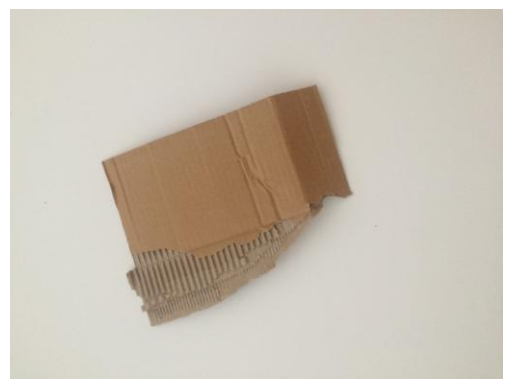

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

dataset_path =  r"C:\Users\MOHD NADEEM\OneDrive\Documents\College_ML_and_DL\Garbage classification\Garbage classification"

category = "cardboard"

image_file = os.listdir(
    os.path.join(dataset_path, category)
)[0]

image_path = os.path.join(
    dataset_path,
    category,
    image_file
)

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10


63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.2219 - loss: 23.5216 - val_accuracy: 0.2374 - val_loss: 1.7836
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.2390 - loss: 1.7780 - val_accuracy: 0.2374 - val_loss: 1.7758
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.2390 - loss: 1.7694 - val_accuracy: 0.2374 - val_loss: 1.7689
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 292ms/step - accuracy: 0.2390 - loss: 1.7618 - val_accuracy: 0.2374 - val_loss: 1.7632
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 274ms/step - accuracy: 0.2390 - loss: 1.7553 - val_accuracy: 0.2374 - val_loss: 1.7583
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.2390 - loss: 1.7497 - val_accuracy: 0.2374 - val_loss: 1.7541
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step - accuracy: 0.2390 - loss: 1.7450 - val_accuracy: 0.2374 - val_loss: 1.7510
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.2390 - loss: 1.7410 - val_accuracy: 0.23

In [10]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.2374 - loss: 1.7445
Test Accuracy: 0.2374245524406433


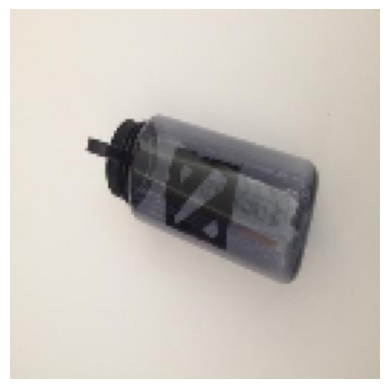

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Class: paper
Confidence: 21.44%


In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = r"C:\Users\MOHD NADEEM\OneDrive\Documents\College_ML_and_DL\Garbage classification\Garbage classification\plastic\plastic1.jpg"

# get required size from model
img_h = model.input_shape[1]
img_w = model.input_shape[2]

img = image.load_img(
    img_path,
    target_size=(img_h, img_w)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = classes

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

In [ ]:
for cls, prob in zip(class_names, prediction[0]):
    print(f"{cls}: {prob*100:.2f}%")

cardboard: 17.90%
glass: 18.85%
metal: 9.50%
paper: 20.03%
plastic: 23.67%
trash: 10.04%
